<a href="https://colab.research.google.com/github/boyranger/ev-charger-behavior/blob/main/spklu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# Setup visualisasi
sns.set(style="whitegrid")
plt.style.use('ggplot')
%matplotlib inline

print("Library berhasil diimport!")

Library berhasil diimport!


In [13]:
import pandas as pd

# Read the data from the Excel file into a pandas DataFrame
df = pd.read_excel('/content/drive/MyDrive/spklu.xlsx')

# You can now use the DataFrame for further processing

In [14]:
# prompt: # Membuat DataFrame

# Display some basic information about the DataFrame
df.info()

# Display the first few rows of the DataFrame
df.head()

# Display descriptive statistics of the DataFrame
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160538 entries, 0 to 160537
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   No            160538 non-null  int64         
 1   Periode       160538 non-null  int64         
 2   Tanggal       160538 non-null  datetime64[ns]
 3   Provinsi      160538 non-null  object        
 4   Pemda/Pemkot  160538 non-null  object        
 5   Nama SPKLU    160538 non-null  object        
 6   EV Charger    160538 non-null  object        
 7   Daya Charger  160538 non-null  object        
 8   kwh           160538 non-null  float64       
 9   durasi        160538 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 12.2+ MB


,No,Periode,Tanggal,kwh
count,160538.000000,160538.000000,160538,160538.000000
mean,80269.500000,202408.598182,2024-07-13 14:13:55.098292736,21.406141
min,1.000000,202301.000000,2023-01-01 03:52:58.189000,0.000000
25%,40135.250000,202403.000000,2024-03-22 11:48:21.936000,7.880000
50%,80269.500000,202409.000000,2024-09-01 17:32:00.488000,19.170000
75%,120403.750000,202412.000000,2024-12-17 17:13:22.249999872,31.030000
max,160538.000000,202502.000000,2025-02-28 23:56:08.163000,99.630000
std,46343.473095,59.215358,NaN,16.292432


In [15]:
df

,No,Periode,Tanggal,Provinsi,Pemda/Pemkot,Nama SPKLU,EV Charger,Daya Charger,kwh,durasi
0,110,202301,2023-01-05 12:26:59.099,JAWA BARAT,KAB. BANDUNG,SPKLU PLN UP3 MAJALAYA,Delta AC Max,22 kW,13.07,01:57:12
1,206,202301,2023-01-08 10:59:42.639,JAWA BARAT,KAB. BANDUNG,SPKLU GEDUNG BUDAYA SABILULUNGAN,Delta AC Max,22 kW,2.76,00:24:47
2,267,202301,2023-01-10 10:27:45.792,JAWA BARAT,KAB. BANDUNG,SPKLU PLN POSKO NAGREG,Delta AC Max,22 kW,2.54,00:22:27
3,299,202301,2023-01-12 15:31:43.829,JAWA BARAT,KAB. BANDUNG,SPKLU PLN POSKO NAGREG,Delta AC Max,22 kW,1.59,00:43:59
4,370,202301,2023-01-14 17:49:22.822,JAWA BARAT,KAB. BANDUNG,SPKLU PLN POSKO CIWIDEY,Delta AC Max,22 kW,0.00,00:05:54
...,...,...,...,...,...,...,...,...,...,...
160533,160047,202502,2025-02-28 08:34:39.222,JAWA BARAT,KOTA TASIKMALAYA,SPKLU PLN ULP TASIKMALAYA KOTA,Delta DC Wallbox,25 kW,24.68,01:03:14
160534,160070,202502,2025-02-28 09:19:41.492,JAWA BARAT,KOTA TASIKMALAYA,SPKLU PLN ULP TASIKMALAYA KOTA,1. Delta AC Max,22 kW,2.94,00:25:58
160535,160087,202502,2025-02-28 09:49:22.600,JAWA BARAT,KOTA TASIKMALAYA,SPKLU PLN ULP TASIKMALAYA KOTA,Delta DC Wallbox,25 kW,12.92,01:09:29
160536,160108,202502,2025-02-28 10:18:45.035,JAWA BARAT,KOTA TASIKMALAYA,SPKLU PLN ULP TASIKMALAYA KOTA,2. Delta AC Max,22 kW,1.24,00:40:30


In [18]:
# Konversi tipe data
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df['durasi'] = pd.to_timedelta(df['durasi'])

# Convert 'Daya Charger' to string before using .str
df['Daya Charger'] = df['Daya Charger'].astype(str).str.replace(' kW', '').astype(float)

# Ekstrak informasi waktu
df['Jam'] = df['Tanggal'].dt.hour
df['Hari'] = df['Tanggal'].dt.day_name()
df['Bulan'] = df['Tanggal'].dt.month_name()

# Urutan hari untuk sorting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Hari'] = pd.Categorical(df['Hari'], categories=day_order, ordered=True)

print("Data berhasil diproses!")
df.head()

Data berhasil diproses!


,No,Periode,Tanggal,Provinsi,Pemda/Pemkot,Nama SPKLU,EV Charger,Daya Charger,kwh,durasi,Jam,Hari,Bulan
0,110,202301,2023-01-05 12:26:59.099,JAWA BARAT,KAB. BANDUNG,SPKLU PLN UP3 MAJALAYA,Delta AC Max,22.0,13.07,0 days 01:57:12,12,Thursday,January
1,206,202301,2023-01-08 10:59:42.639,JAWA BARAT,KAB. BANDUNG,SPKLU GEDUNG BUDAYA SABILULUNGAN,Delta AC Max,22.0,2.76,0 days 00:24:47,10,Sunday,January
2,267,202301,2023-01-10 10:27:45.792,JAWA BARAT,KAB. BANDUNG,SPKLU PLN POSKO NAGREG,Delta AC Max,22.0,2.54,0 days 00:22:27,10,Tuesday,January
3,299,202301,2023-01-12 15:31:43.829,JAWA BARAT,KAB. BANDUNG,SPKLU PLN POSKO NAGREG,Delta AC Max,22.0,1.59,0 days 00:43:59,15,Thursday,January
4,370,202301,2023-01-14 17:49:22.822,JAWA BARAT,KAB. BANDUNG,SPKLU PLN POSKO CIWIDEY,Delta AC Max,22.0,0.00,0 days 00:05:54,17,Saturday,January


<ipython-input-19-973bfa0030fb>:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_hour_day = df.pivot_table(index='Hari', columns='Jam', values='kwh', aggfunc='sum')


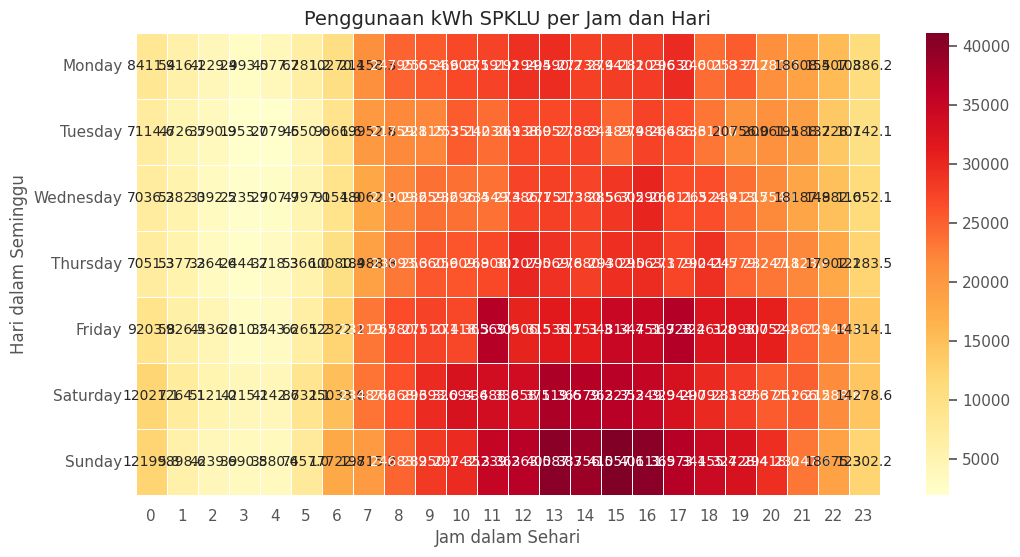

In [19]:
# Pivot table untuk heatmap
pivot_hour_day = df.pivot_table(index='Hari', columns='Jam', values='kwh', aggfunc='sum')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_hour_day, cmap='YlOrRd', annot=True, fmt='.1f', linewidths=.5)
plt.title('Penggunaan kWh SPKLU per Jam dan Hari', fontsize=14)
plt.xlabel('Jam dalam Sehari', fontsize=12)
plt.ylabel('Hari dalam Seminggu', fontsize=12)
plt.show()

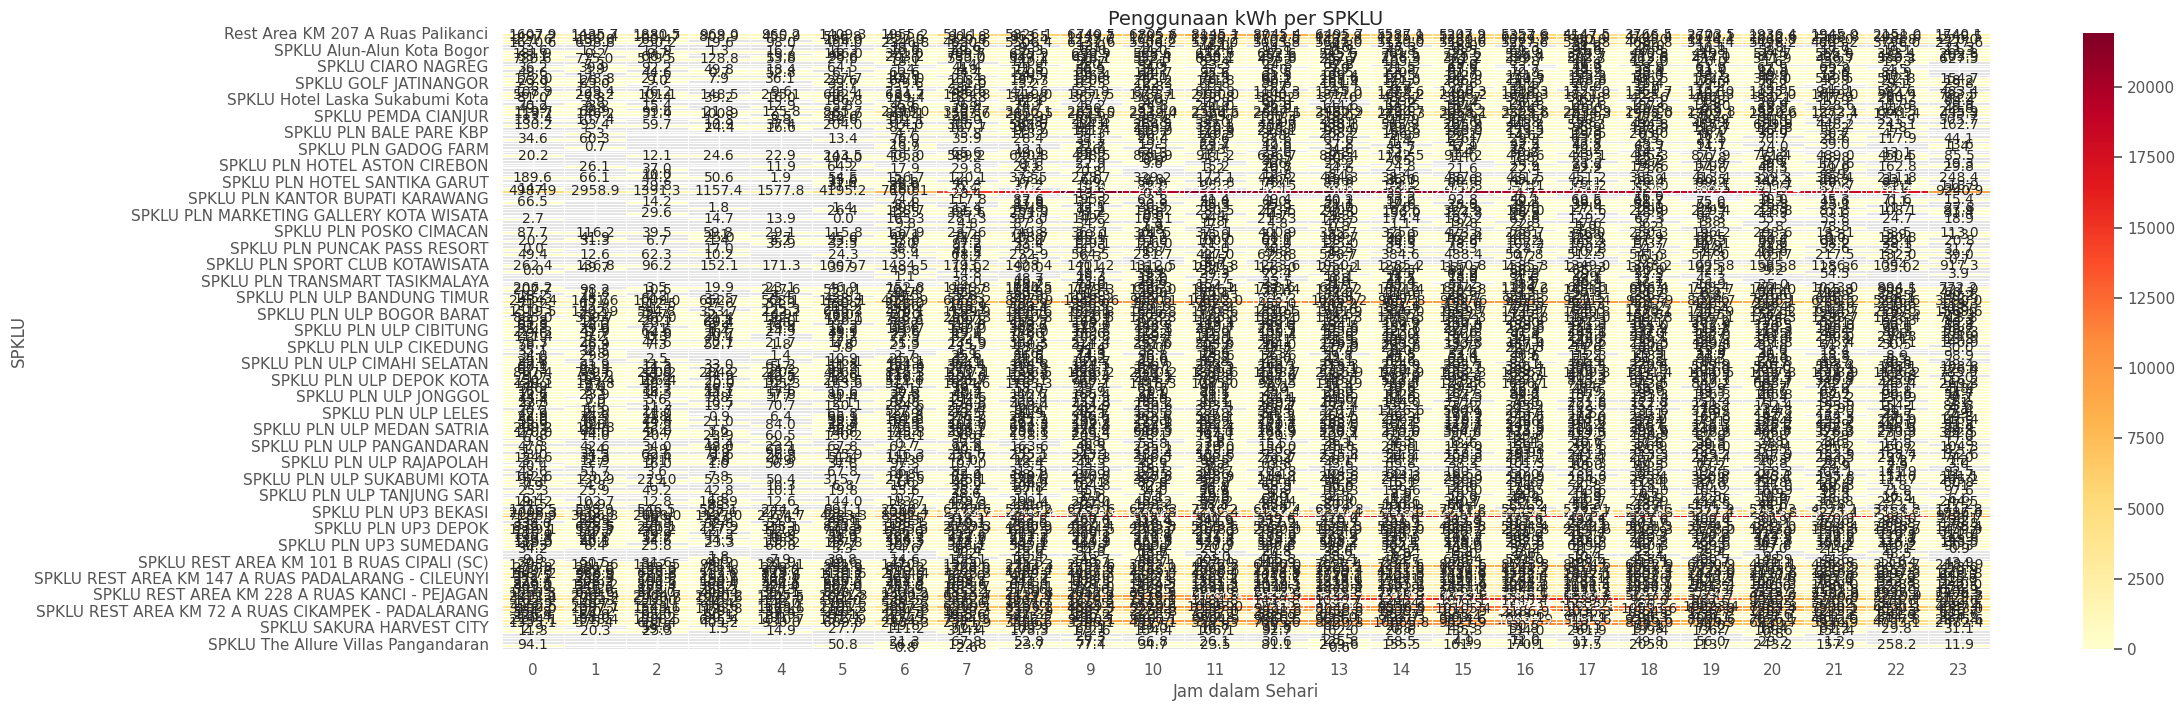

In [22]:
# Pivot table untuk heatmap per SPKLU
pivot_spklu = df.pivot_table(index='Nama SPKLU', columns='Jam', values='kwh', aggfunc='sum')

plt.figure(figsize=(24, 8))
sns.heatmap(pivot_spklu, cmap='YlOrRd', annot=True, fmt='.1f', linewidths=.5)
plt.title('Penggunaan kWh per SPKLU', fontsize=14)
plt.xlabel('Jam dalam Sehari', fontsize=12)
plt.ylabel('SPKLU', fontsize=12)
plt.show()

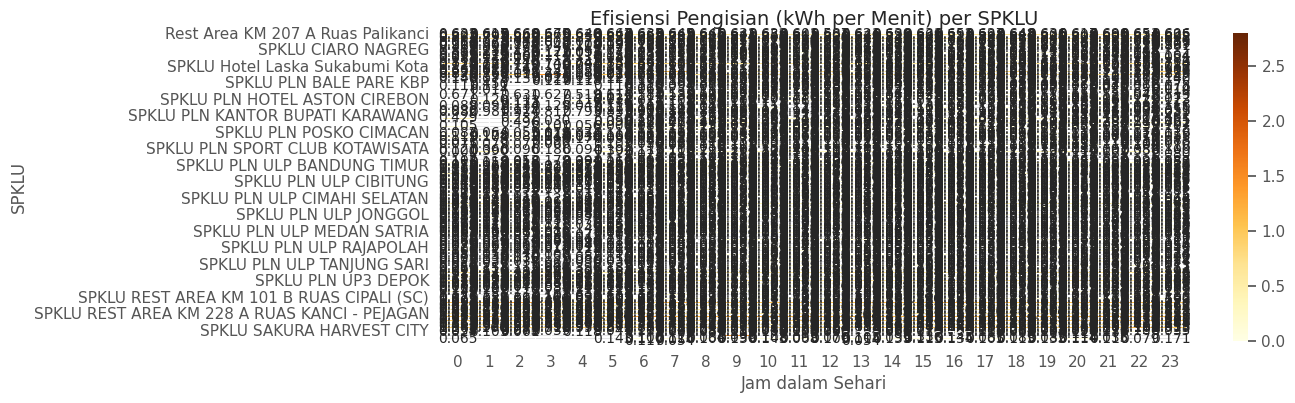

In [23]:
# Hitung efisiensi (kWh per menit)
df['durasi_menit'] = df['durasi'].dt.total_seconds() / 60
df['efisiensi'] = df['kwh'] / df['durasi_menit']

# Pivot table untuk heatmap efisiensi
pivot_efisiensi = df.pivot_table(index='Nama SPKLU', columns='Jam', values='efisiensi', aggfunc='mean')

plt.figure(figsize=(12, 4))
sns.heatmap(pivot_efisiensi, cmap='YlOrBr', annot=True, fmt='.3f', linewidths=.5)
plt.title('Efisiensi Pengisian (kWh per Menit) per SPKLU', fontsize=14)
plt.xlabel('Jam dalam Sehari', fontsize=12)
plt.ylabel('SPKLU', fontsize=12)
plt.show()

<ipython-input-24-da0090d2565d>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Nama SPKLU', y='kwh', estimator=sum, ci=None)


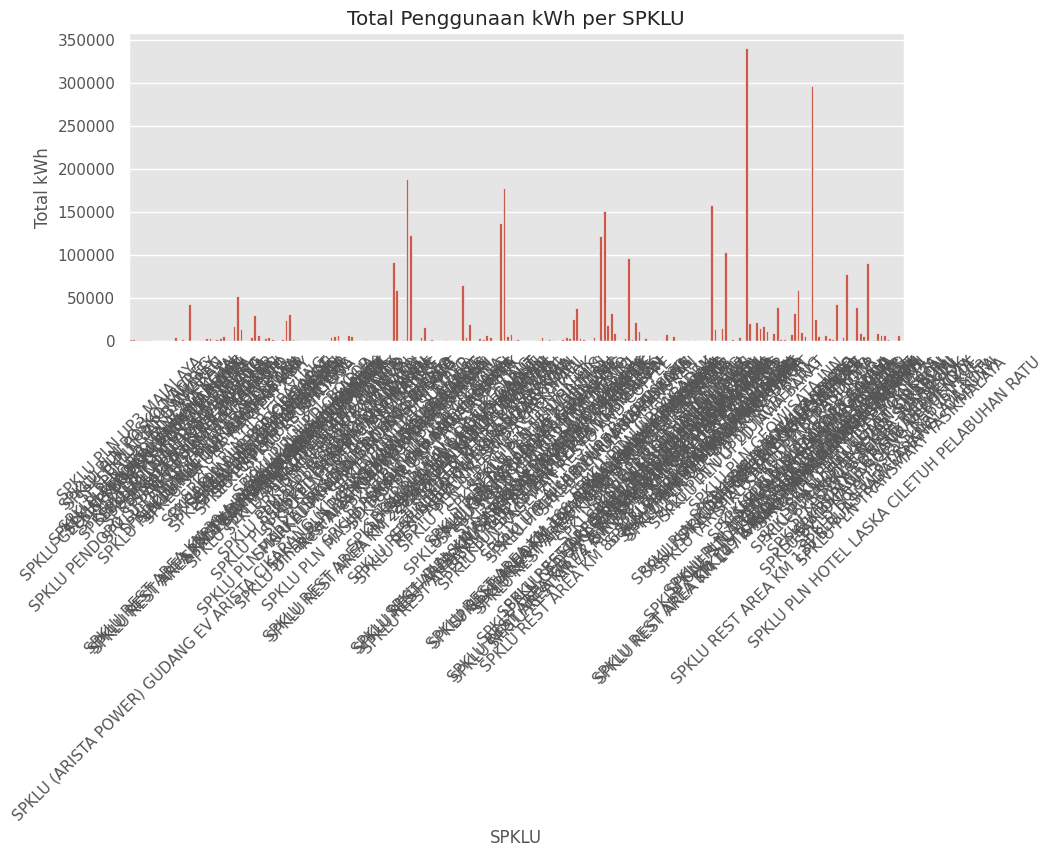

In [24]:
plt.figure(figsize=(10, 4))
sns.barplot(data=df, x='Nama SPKLU', y='kwh', estimator=sum, ci=None)
plt.title('Total Penggunaan kWh per SPKLU')
plt.xlabel('SPKLU')
plt.ylabel('Total kWh')
plt.xticks(rotation=45)
plt.show()

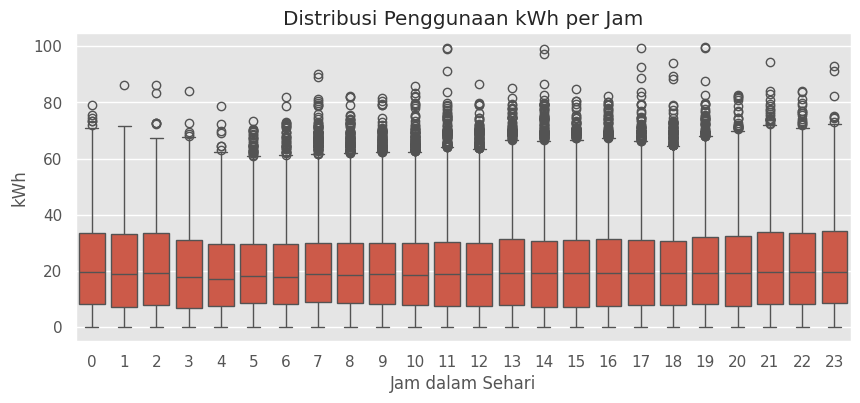

In [25]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Jam', y='kwh')
plt.title('Distribusi Penggunaan kWh per Jam')
plt.xlabel('Jam dalam Sehari')
plt.ylabel('kWh')
plt.show()

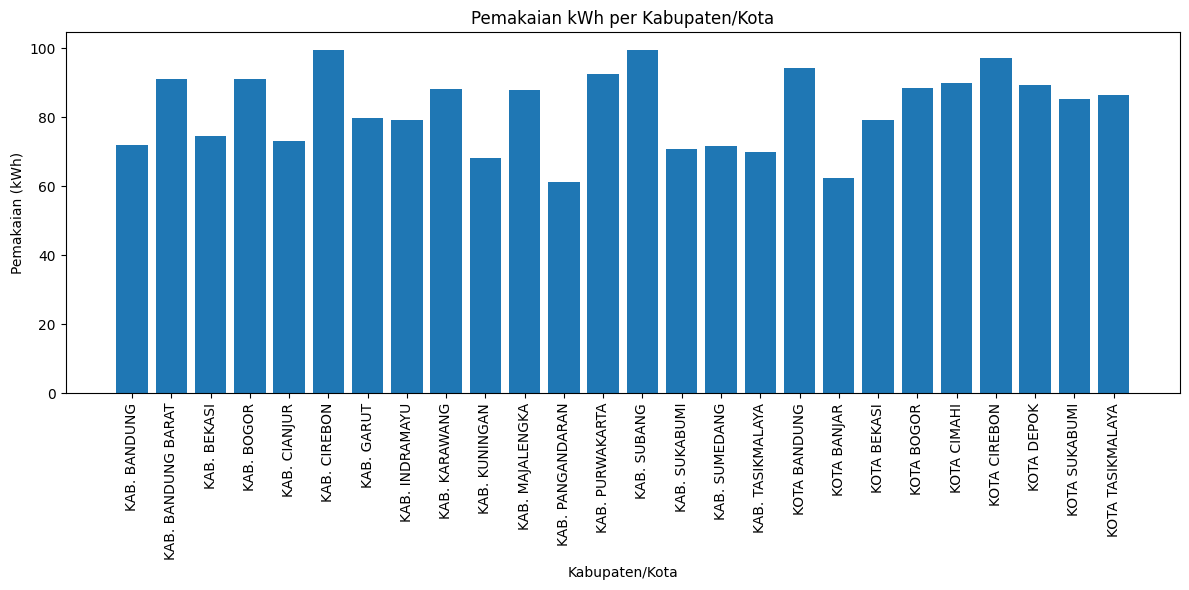

In [5]:
# prompt: buat grafik pemakaian kwh per kab/kota

import matplotlib.pyplot as plt

# Assuming 'Kabupaten/Kota' and 'Pemakaian (kWh)' are column names in your DataFrame
kabupaten_kota = df['Pemda/Pemkot']
pemakaian_kwh = df['kwh']

plt.figure(figsize=(12, 6))  # Adjust figure size as needed
plt.bar(kabupaten_kota, pemakaian_kwh)
plt.xlabel('Kabupaten/Kota')
plt.ylabel('Pemakaian (kWh)')
plt.title('Pemakaian kWh per Kabupaten/Kota')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability if needed
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()


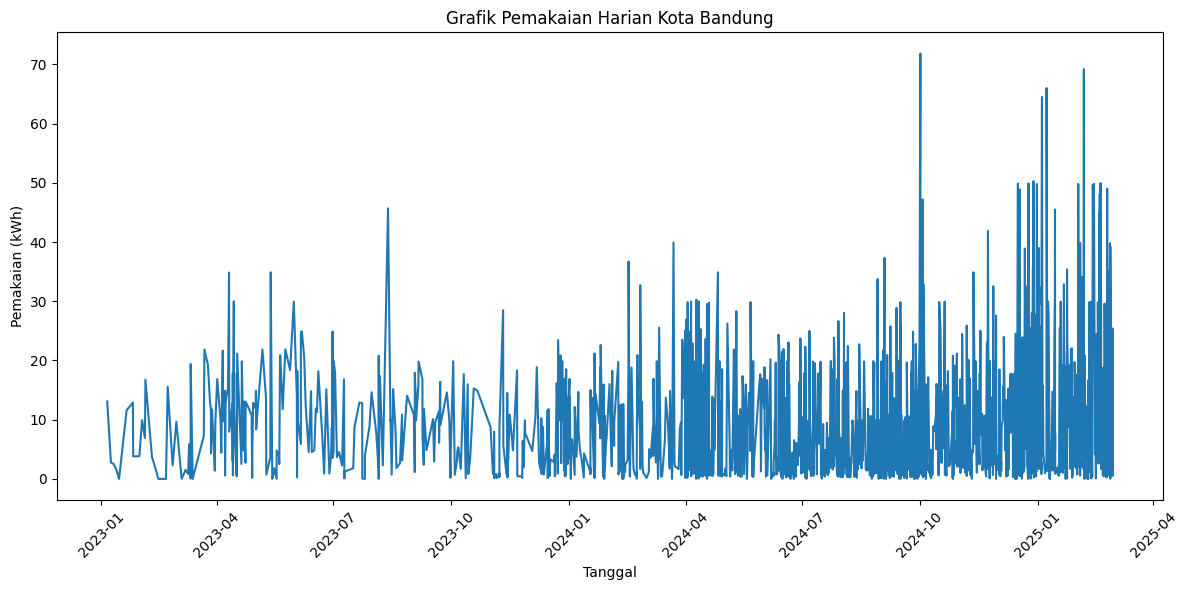

In [5]:
# prompt: grafik  profile pmakaian harian kota bandung

import pandas as pd
import matplotlib.pyplot as plt

# Assuming your data is in a DataFrame called 'df'
# and you have columns named 'Tanggal' and 'Pemakaian (kWh)'

# If 'Tanggal' is not a datetime object, convert it
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

# Filter data for Bandung
bandung_data = df[df['Pemda/Pemkot'] == 'KAB. BANDUNG']

# Group data by date and sum the daily consumption
daily_consumption = bandung_data.groupby('Tanggal')['kwh'].sum()


plt.figure(figsize=(12, 6))
plt.plot(daily_consumption.index, daily_consumption.values)
plt.xlabel('Tanggal')
plt.ylabel('Pemakaian (kWh)')
plt.title('Grafik Pemakaian Harian Kota Bandung')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


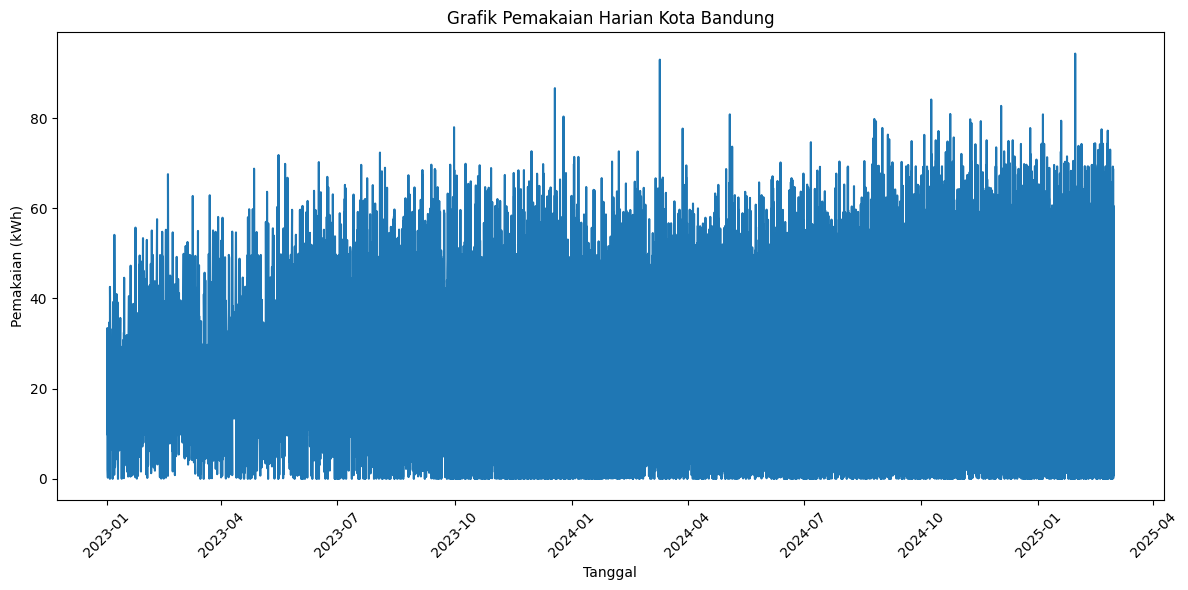

In [6]:
# prompt: grafik  profile pmakaian harian kota bandung

import pandas as pd
import matplotlib.pyplot as plt

# Assuming your data is in a DataFrame called 'df'
# and you have columns named 'Tanggal' and 'Pemakaian (kWh)'

# If 'Tanggal' is not a datetime object, convert it
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

# Filter data for Bandung
bandung_data = df[df['Pemda/Pemkot'] == 'KOTA BANDUNG']

# Group data by date and sum the daily consumption
daily_consumption = bandung_data.groupby('Tanggal')['kwh'].sum()


plt.figure(figsize=(12, 6))
plt.plot(daily_consumption.index, daily_consumption.values)
plt.xlabel('Tanggal')
plt.ylabel('Pemakaian (kWh)')
plt.title('Grafik Pemakaian Harian Kota Bandung')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


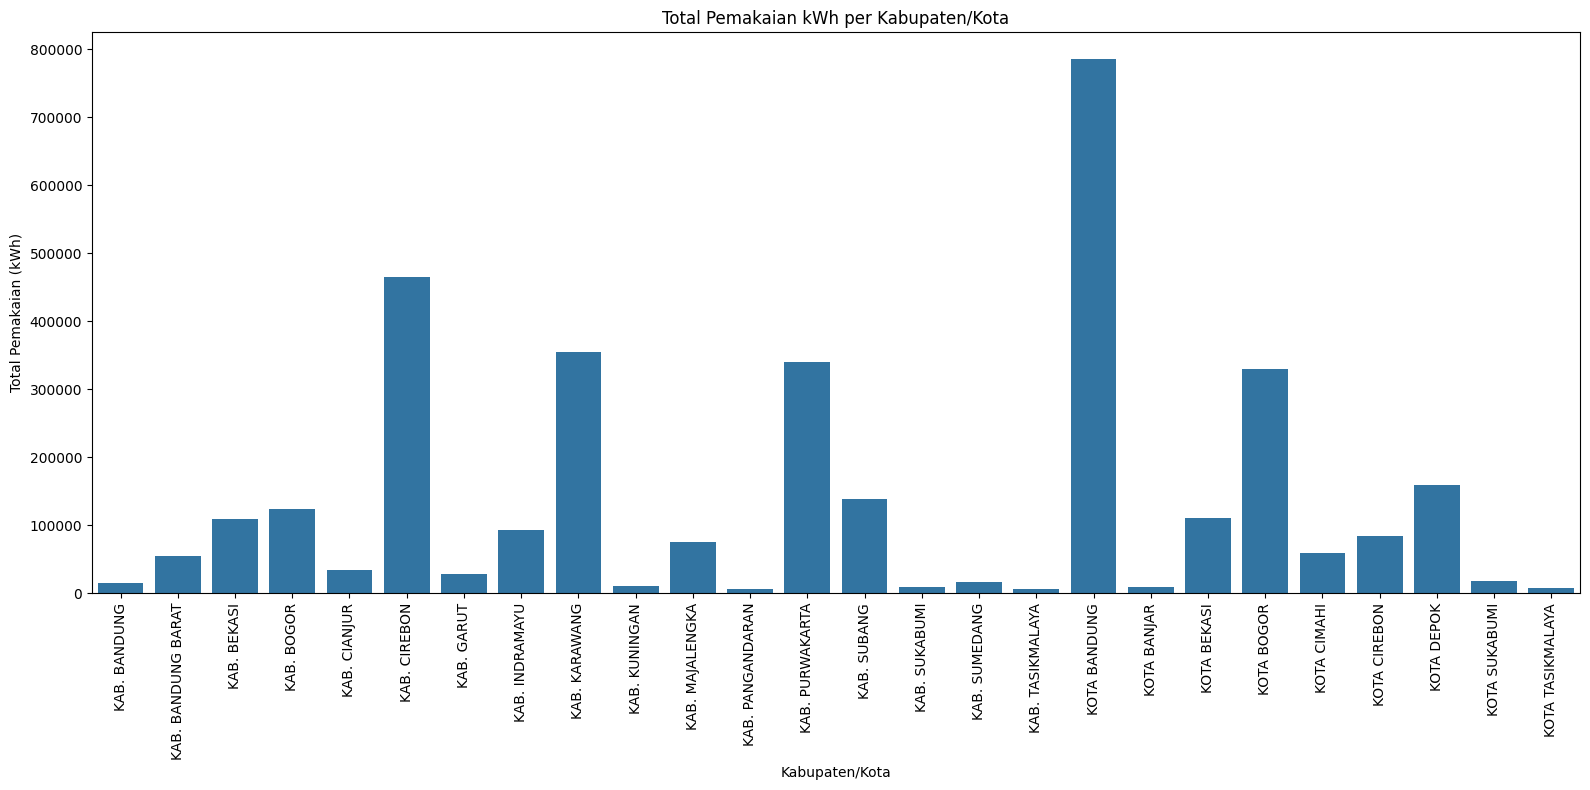

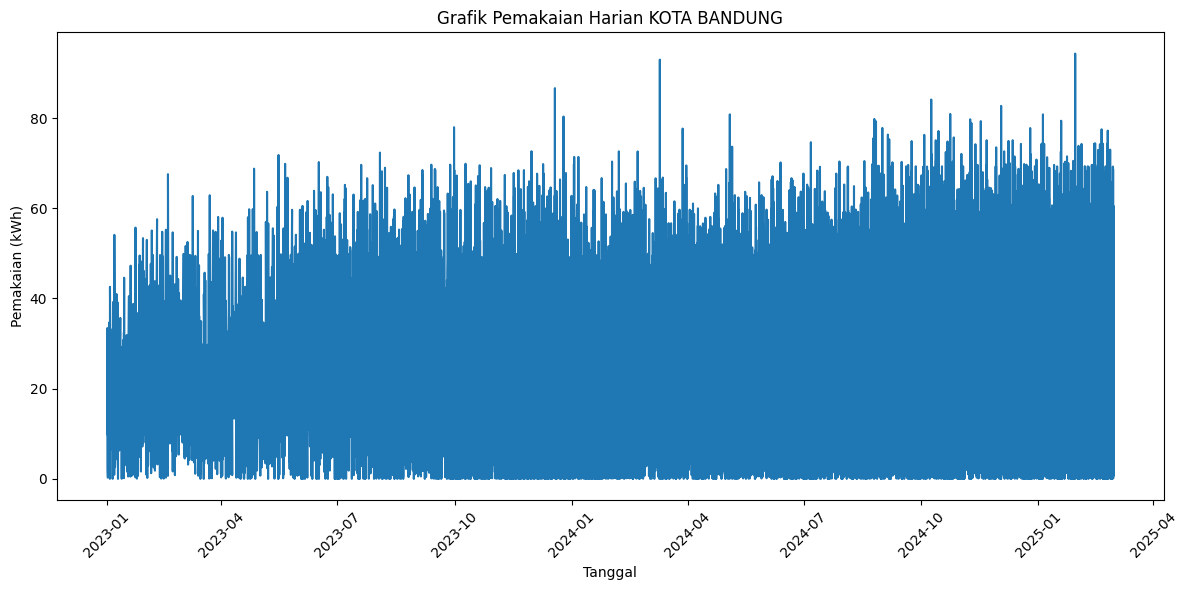

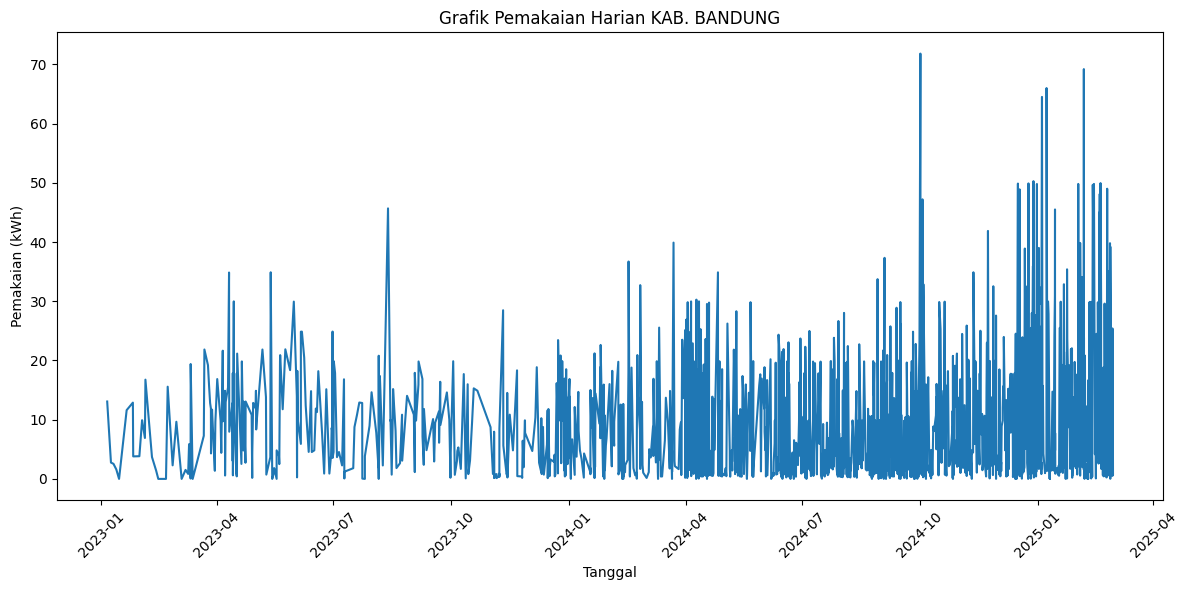

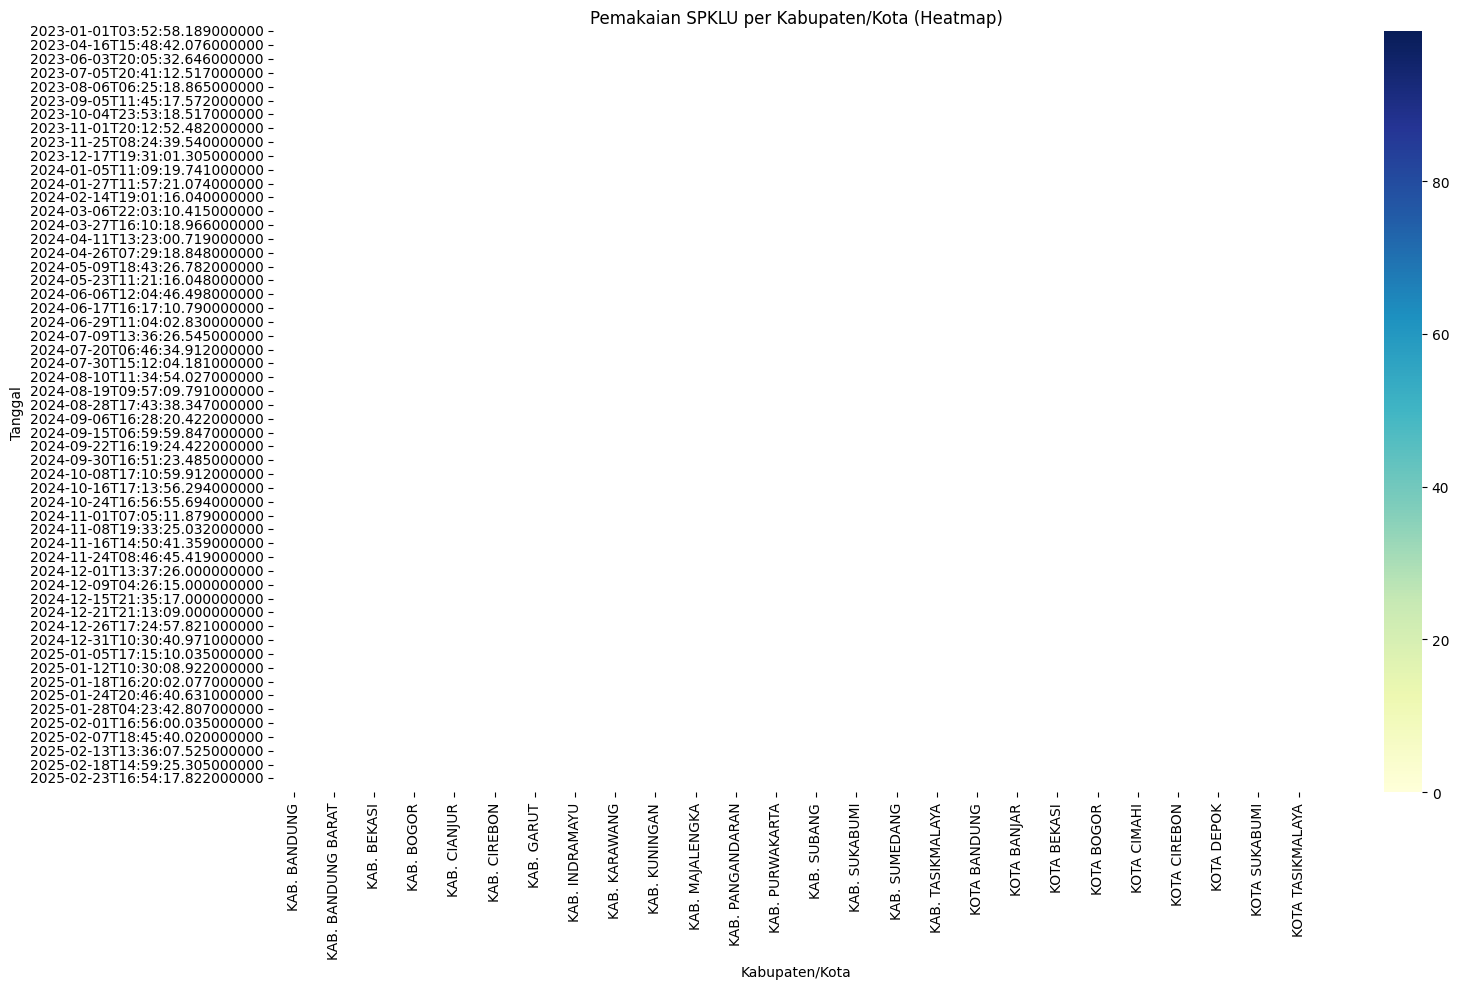

In [7]:
# prompt: Analisis Spasial dan Temporal Penggunaan SPKLU di Jawa Barat

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the data from the Excel file into a pandas DataFrame
df = pd.read_excel('/content/drive/MyDrive/spklu.xlsx')

# Convert 'Tanggal' column to datetime objects
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

# --- Spatial Analysis: Total Consumption per Region ---
spatial_df = df.groupby('Pemda/Pemkot')['kwh'].sum().reset_index()

plt.figure(figsize=(16, 8))
sns.barplot(x='Pemda/Pemkot', y='kwh', data=spatial_df)
plt.xlabel('Kabupaten/Kota')
plt.ylabel('Total Pemakaian (kWh)')
plt.title('Total Pemakaian kWh per Kabupaten/Kota')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# --- Temporal Analysis: Daily Consumption per Region ---
def plot_daily_consumption(region):
    region_data = df[df['Pemda/Pemkot'] == region]
    daily_consumption = region_data.groupby('Tanggal')['kwh'].sum()

    plt.figure(figsize=(12, 6))
    plt.plot(daily_consumption.index, daily_consumption.values)
    plt.xlabel('Tanggal')
    plt.ylabel('Pemakaian (kWh)')
    plt.title(f'Grafik Pemakaian Harian {region}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Example usage: Plotting for Kota Bandung and Kab. Bandung
plot_daily_consumption('KOTA BANDUNG')
plot_daily_consumption('KAB. BANDUNG')


# --- Combined Spatial and Temporal Analysis (Heatmap) ---
# Create a pivot table for visualization
heatmap_data = df.pivot_table(index='Tanggal', columns='Pemda/Pemkot', values='kwh', aggfunc='sum')

plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False, fmt=".0f", linewidths=.5)  # Use a colormap
plt.title("Pemakaian SPKLU per Kabupaten/Kota (Heatmap)")
plt.xlabel("Kabupaten/Kota")
plt.ylabel("Tanggal")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


1. Analisis Spasial dan Temporal Penggunaan SPKLU di Jawa Barat
2. Dampak EV terhadap Beban Jaringan Listrik
3. Analisis Emisi dan Potensi Integrasi Energi Terbarukan
4. Studi Perilaku Pengguna EV (Survei preferensi pengguna (pengisian rumah vs. SPKLU, tarif vs. kepraktisan)
5. "Pemetaan Kebutuhan Infrastruktur SPKLU di Jawa Barat Berbasis Proyeksi Pertumbuhan EV 2030"
via deepseek eta.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan kolom 'Tanggal' adalah tipe datetime
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

# Buat pivot table untuk heatmap
heatmap_data = df.pivot_table(
    index='Tanggal',
    columns='Pemda/Pemkot',
    values='kwh',
    aggfunc='sum',
    fill_value=0  # Mengisi nilai kosong dengan 0
)

# Membuat heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,  # Set True jika ingin menampilkan angka
    fmt=".1f",    # Format angka jika annot=True
    linewidths=.5,
    cbar_kws={'label': 'Pemakaian (kWh)'}  # Menambahkan label pada color bar
)

# Pengaturan label dan judul
plt.title("Pemakaian SPKLU per Kabupaten/Kota (Heatmap)")
plt.xlabel("Kabupaten/Kota")
plt.ylabel("Tanggal")
plt.xticks(rotation=45, ha='right')  # Memutar label sumbu X
plt.yticks(rotation=0)  # Label sumbu Y tetap horizontal
plt.tight_layout()

plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7d42318c6f20> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7d42318c4b80> (for post_execute):


KeyboardInterrupt: 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# Buat data contoh
np.random.seed(42)
zones = ['Zona A', 'Zona B', 'Zona C', 'Zona D', 'Zona E']
days = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
hours = list(range(24))

# Generate random data dengan pola tertentu
data = []
for day in days:
    for hour in hours:
        for zone in zones:
            # Baseline usage
            usage = np.random.normal(loc=50, scale=10)

            # Tambahkan pola harian
            if 8 <= hour <= 18:  # Siang hari
                usage += np.random.normal(loc=30, scale=5)
            elif 19 <= hour <= 22:  # Malam aktif
                usage += np.random.normal(loc=20, scale=5)
            else:  # Tengah malam
                usage -= np.random.normal(loc=10, scale=3)

            # Tambahkan pola akhir pekan
            if day in ['Sabtu', 'Minggu']:
                if 10 <= hour <= 18:
                    usage += np.random.normal(loc=15, scale=3)
                else:
                    usage -= np.random.normal(loc=5, scale=2)

            # Tambahkan variasi per zona
            if zone == 'Zona Industri':
                usage *= 1.8
            elif zone == 'Zona Komersial':
                usage *= 1.4

            usage = max(10, usage)  # Pastikan tidak negatif

            data.append([zone, day, hour, round(usage, 2)])

# Buat DataFrame
df = pd.DataFrame(data, columns=['Zona', 'Hari', 'Jam', 'kWh'])

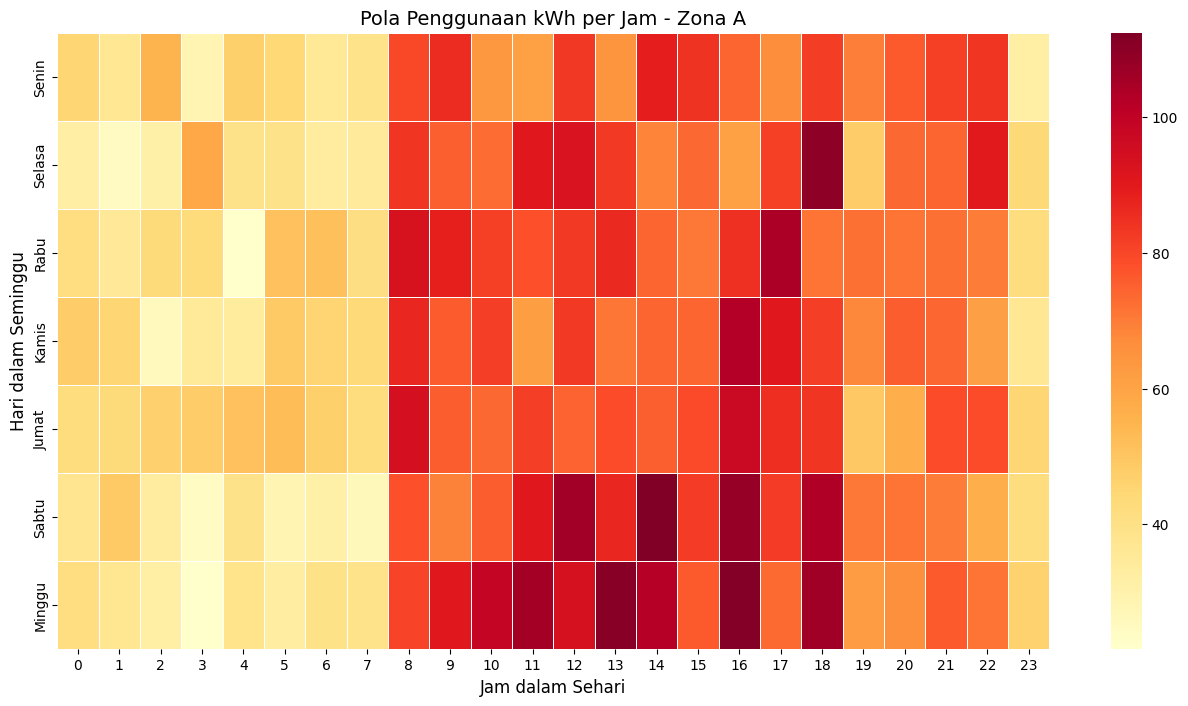

In [2]:
# Filter data untuk satu zona
zona_a = df[df['Zona'] == 'Zona A']

# Pivot table untuk heatmap
pivot_a = zona_a.pivot_table(index='Hari', columns='Jam', values='kWh', aggfunc='mean')

# Urutkan hari secara manual
day_order = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
pivot_a = pivot_a.reindex(day_order)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_a, cmap='YlOrRd', annot=False, fmt='.1f', linewidths=.5)
plt.title('Pola Penggunaan kWh per Jam - Zona A', fontsize=14)
plt.xlabel('Jam dalam Sehari', fontsize=12)
plt.ylabel('Hari dalam Seminggu', fontsize=12)
plt.show()

In [3]:
# Rata-rakan penggunaan per zona per jam
avg_usage = df.groupby(['Zona', 'Jam'])['kWh'].mean().reset_index()

plt.figure(figsize=(16, 6))
sns.heatmap(avg_usage.pivot('Zona', 'Jam', 'kWh'),
            cmap='YlOrRd',
            annot=True,
            fmt='.1f',
            linewidths=.5,
            annot_kws={'size': 8})
plt.title('Rata-rata Penggunaan kWh per Jam di Setiap Zona', fontsize=14)
plt.xlabel('Jam dalam Sehari', fontsize=12)
plt.ylabel('Zona', fontsize=12)
plt.show()

TypeError: DataFrame.pivot() takes 1 positional argument but 4 were given

<Figure size 1600x600 with 0 Axes>

In [4]:
# Hitung total penggunaan per zona per hari
daily_usage = df.groupby(['Zona', 'Hari'])['kWh'].sum().reset_index()

# Pivot untuk heatmap
pivot_daily = daily_usage.pivot('Zona', 'Hari', 'kWh')
pivot_daily = pivot_daily[day_order]  # Urutkan hari

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_daily,
            cmap='YlOrRd',
            annot=True,
            fmt='.1f',
            linewidths=.5)
plt.title('Total Penggunaan kWh Harian per Zona', fontsize=14)
plt.xlabel('Hari', fontsize=12)
plt.ylabel('Zona', fontsize=12)
plt.show()

TypeError: DataFrame.pivot() takes 1 positional argument but 4 were given